In [5]:
# Example plot ADCP
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [6]:
folder_dataset = r'U:\HybridDune\,Dataset\Hydrodynamics\ADCP'  # Adapt as needed

file_ADCP1 = folder_dataset + r'\ADCP1\Waves\ADCP1_WAVES_LOG8.txt'
file_ADCP2 = folder_dataset + r'\ADCP2\Waves\ADCP2_000_000_LOG8.txt'

# Define column names for the first 15 columns (ignore the dir per depth bin)
col_names = [
    "sample_number", "yy", "mm", "dd", "hh", "mi", "ss", "sss",
    "Hs", "Tp", "Dp", "depth", "H1_10th", "Tm01", "Dm"
]

def load_and_process_log8_adcp(file_path):
    df = pd.read_csv(
        file_path,
        sep=",",
        header=None,
        names=col_names,
        usecols=range(15)
    )

    # Process datetime
    df["datetime"] = pd.to_datetime(
        "20" + df["yy"].astype(str).str.zfill(2) + "-" +
        df["mm"].astype(str).str.zfill(2) + "-" +
        df["dd"].astype(str).str.zfill(2) + " " +
        df["hh"].astype(str).str.zfill(2) + ":" +
        df["mi"].astype(str).str.zfill(2) + ":" +
        df["ss"].astype(str).str.zfill(2) + "." +
        df["sss"].astype(str).str.zfill(3),
        format="%Y-%m-%d %H:%M:%S.%f"
    )
    df = df.drop(columns=col_names[:8]) # Drop all the separate year, month, etc columns
    cols = df.columns.tolist()          # Reorder columns to have datetime first
    cols.insert(0, cols.pop(cols.index('datetime')))
    df = df[cols]

    # Filter: make -1 values NaN
    df.replace(-1, np.nan, inplace=True)
    return df

df1 = load_and_process_log8_adcp(file_ADCP1)
df2 = load_and_process_log8_adcp(file_ADCP2)

df1.head()

,datetime,Hs,Tp,Dp,depth,H1_10th,Tm01,Dm
0,2024-12-17 08:00:00,NaN,NaN,NaN,2.0,NaN,NaN,NaN
1,2024-12-17 10:00:00,0.93,5.6,287.0,13206.0,1.18,5.1,287.0
2,2024-12-17 12:00:00,0.91,5.1,290.0,13011.0,1.15,5.1,288.0
3,2024-12-17 14:00:00,0.97,4.7,262.0,13674.0,1.24,4.9,280.0
4,2024-12-17 16:00:00,0.71,6.1,320.0,14843.0,0.90,4.9,318.0


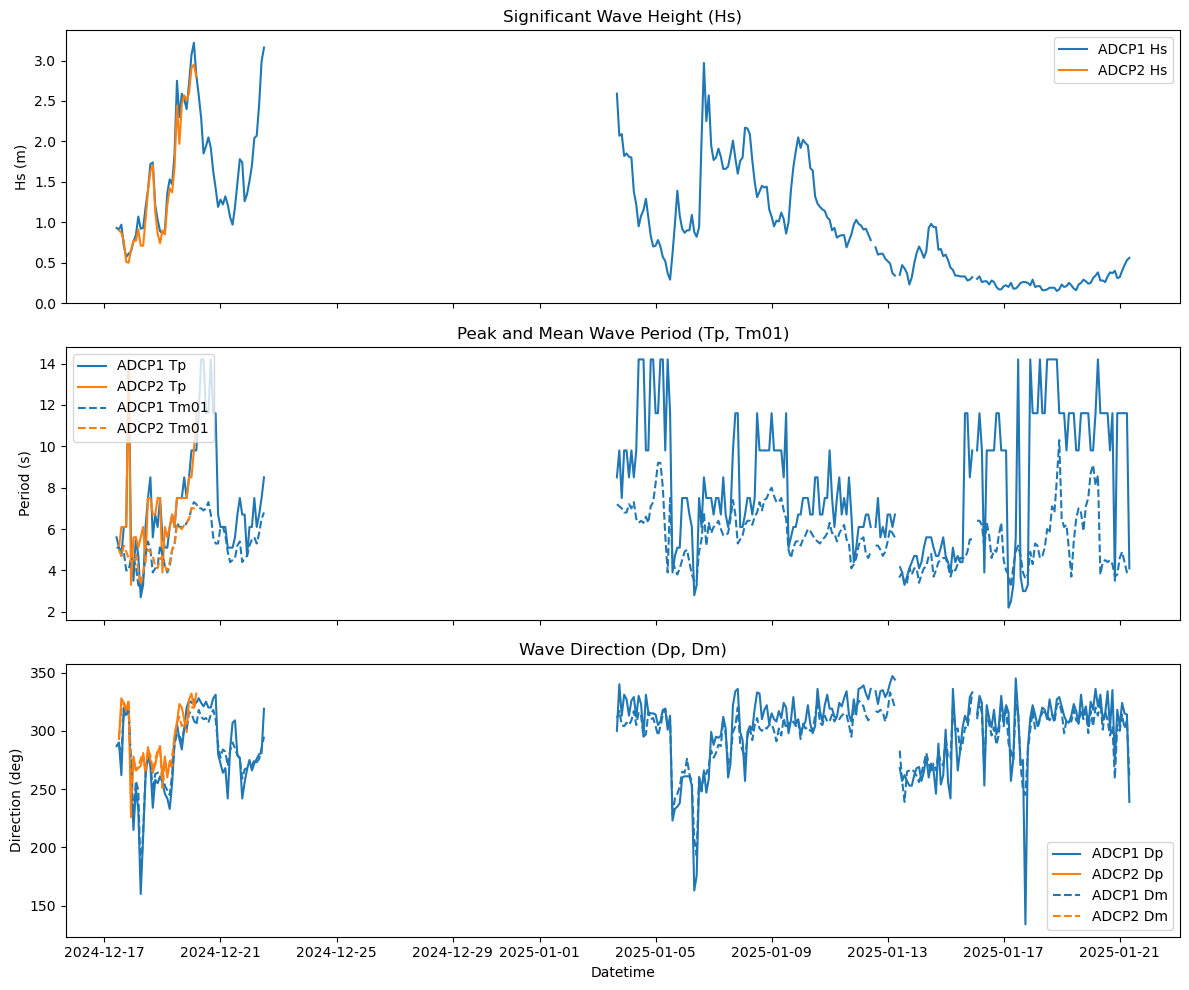

In [7]:
# Plot adcp data
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1. Hs for both ADCPS
axs[0].plot(df1['datetime'], df1['Hs'], label='ADCP1 Hs', color='tab:blue')
axs[0].plot(df2['datetime'], df2['Hs'], label='ADCP2 Hs', color='tab:orange')
axs[0].set_ylabel('Hs (m)')
axs[0].legend()
axs[0].set_title('Significant Wave Height (Hs)')

# 2. Tp and Tm01 (both ADCP1 blue, ADCP2 orange)
axs[1].plot(df1['datetime'], df1['Tp'], label='ADCP1 Tp', color='tab:blue')
axs[1].plot(df2['datetime'], df2['Tp'], label='ADCP2 Tp', color='tab:orange')
axs[1].plot(df1['datetime'], df1['Tm01'], label='ADCP1 Tm01', color='tab:blue', linestyle='--')
axs[1].plot(df2['datetime'], df2['Tm01'], label='ADCP2 Tm01', color='tab:orange', linestyle='--')
axs[1].set_ylabel('Period (s)')
axs[1].legend()
axs[1].set_title('Peak and Mean Wave Period (Tp, Tm01)')

# 3. Dp and Dm (both ADCP1 blue, ADCP2 orange)
axs[2].plot(df1['datetime'], df1['Dp'], label='ADCP1 Dp', color='tab:blue')
axs[2].plot(df2['datetime'], df2['Dp'], label='ADCP2 Dp', color='tab:orange')
axs[2].plot(df1['datetime'], df1['Dm'], label='ADCP1 Dm', color='tab:blue', linestyle='--')
axs[2].plot(df2['datetime'], df2['Dm'], label='ADCP2 Dm', color='tab:orange', linestyle='--')

axs[2].set_ylabel('Direction (deg)')
axs[2].legend()
axs[2].set_title('Wave Direction (Dp, Dm)')

axs[2].set_xlabel('Datetime')
plt.tight_layout()
plt.show()